# "It's a medium effect"

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/effect-size-reader/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/effect-size-reader/demo.ipynb)

Cohen's d = 0.5 gets reported as a fact about how big something is. It is a *ratio* - a difference
in means over a standard deviation - and the denominator is doing far more work than anyone says
out loud.

This notebook fixes d **exactly** and changes nothing else but the shape of the distribution.

That is the whole trick, and it is worth being precise about it: every population below is
standardised to population mean 0 and population SD 1 using its **analytic** moments, never sample
ones, and then the treated group is shifted by exactly `d`. So the population Cohen's d is exactly
`d` for a normal, a skewed, a heavy-tailed and a contaminated distribution alike.

Any disagreement you see between the other effect-size metrics therefore **cannot** be a
difference in how big the effect is. It is the metrics answering different questions.

What gets measured:

1. **Calibration** - reproduce a closed form before reporting anything that has none
2. **The headline** - one d, six shapes, six different answers to "how often does treatment win?"
3. **The estimators** - what a sample says, and where Hedges' correction stops working
4. **Robustness** - one contaminated value in a hundred, and which metric breaks
5. **Significance versus magnitude** - plus a SciPy defect that put a wrong table in this notebook
6. **The median split** - and the shapes where the advice against it is simply false

## Setup

The engine is the repository's own `effectsize.py`, extracted verbatim so this notebook and the
library cannot disagree. The design lists and seeds are the library's too, so the rows printed
below are the same cells that appear in `evidence.txt`.

In [1]:
from __future__ import annotations

import math
from typing import Callable, Dict, List, Optional, Sequence, Tuple

import numpy as np
from scipy import stats

ALPHA = 0.05

Z99 = 2.5758293035489004

CHUNK = 2000

REFERENCE_DRAWS = 20_000_000

def wilson(rate: float, n: int, z: float = Z99) -> Tuple[float, float]:
    """Wilson score interval for a measured proportion - used for every rate comparison here."""
    if n <= 0:
        return (0.0, 1.0)
    denom = 1.0 + z * z / n
    centre = (rate + z * z / (2.0 * n)) / denom
    half = z * math.sqrt(rate * (1.0 - rate) / n + z * z / (4.0 * n * n)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)

def mc_interval(values: np.ndarray, z: float = Z99) -> Tuple[float, float]:
    """99% interval on a Monte Carlo mean - so a 'difference' is never read off two point
    estimates whose error bars overlap."""
    m = float(values.mean())
    se = float(values.std(ddof=1) / math.sqrt(values.size))
    return m - z * se, m + z * se

LOGNORMAL_S = 0.75

CONTAM_SCALE = 5.0

CONTAM_SHARE = 0.05

def _standard(name: str, size: Tuple[int, ...], rng: np.random.Generator) -> np.ndarray:
    """Draw from `name` already standardised to population mean 0, population SD 1.

    Standardising by the analytic moments rather than the sample's is the load-bearing detail.
    Dividing by a sample SD would make the true d only correct on average, and every claim below
    is about a d that is correct exactly.
    """
    if name == "normal":
        return rng.standard_normal(size)
    if name == "t5":
        # Var(t_v) = v/(v-2) = 5/3.
        return rng.standard_t(5, size) / math.sqrt(5.0 / 3.0)
    if name == "uniform":
        return (rng.random(size) - 0.5) * math.sqrt(12.0)
    if name == "exponential":
        # Exp(1) has mean 1 and SD 1, so centring is all that is needed. Skew 2.
        return rng.exponential(1.0, size) - 1.0
    if name == "lognormal":
        s = LOGNORMAL_S
        raw = np.exp(s * rng.standard_normal(size))
        mean = math.exp(s * s / 2.0)
        sd = math.sqrt((math.exp(s * s) - 1.0) * math.exp(s * s))
        return (raw - mean) / sd
    if name == "contaminated":
        # 95% N(0,1) + 5% N(0,5): symmetric, unimodal, and a variance dominated by the tail.
        pick = rng.random(size) < CONTAM_SHARE
        base = rng.standard_normal(size)
        sd = math.sqrt((1 - CONTAM_SHARE) + CONTAM_SHARE * CONTAM_SCALE ** 2)
        return np.where(pick, base * CONTAM_SCALE, base) / sd
    raise ValueError(f"unknown population: {name}")

SHAPES: Tuple[str, ...] = ("normal", "uniform", "t5", "contaminated", "lognormal", "exponential")

SKEWED: Tuple[str, ...] = ("lognormal", "exponential")

def draw_pair(
    shape: str, d: float, n1: int, n2: int, reps: int, rng: np.random.Generator
) -> Tuple[np.ndarray, np.ndarray]:
    """Control and treated samples. Population Cohen's d is EXACTLY `d`, whatever the shape."""
    a = _standard(shape, (reps, n1), rng)
    b = _standard(shape, (reps, n2), rng) + d
    return a, b

def true_prob_superiority(shape: str, d: float, draws: int = REFERENCE_DRAWS,
                          seed: int = 0) -> Tuple[float, float]:
    """P(treated > control) for the POPULATIONS, by reference sampling. Returns (value, 99% CI).

    For normal data this has a closed form, Phi(d/sqrt(2)), which `test_effectsize.py` checks this
    routine against - the calibration cell. For every other shape there is no closed form, which
    is exactly why the number is worth computing rather than assuming.
    """
    rng = np.random.default_rng(1000 + seed)
    hits = 0
    total = 0
    block = 2_000_000
    wins: List[float] = []
    while total < draws:
        take = min(block, draws - total)
        a = _standard(shape, (take,), rng)
        b = _standard(shape, (take,), rng) + d
        w = float((b > a).mean())
        wins.append(w)
        hits += int((b > a).sum())
        total += take
    p = hits / total
    lo, hi = wilson(p, total)
    return p, (hi - lo) / 2.0

def analytic_prob_superiority(d: float) -> float:
    """P(X > Y) for two normals separated by d standard deviations. Normal data ONLY."""
    return float(stats.norm.cdf(d / math.sqrt(2.0)))

METRICS: Tuple[str, ...] = (
    "cohens_d", "hedges_g", "glass_delta", "prob_superiority", "cliffs_delta",
    "point_biserial_r", "log_odds_median_split",
)

def metrics(a: np.ndarray, b: np.ndarray) -> Dict[str, np.ndarray]:
    """Every effect-size summary in this build, on one pair of samples (vectorised over rows)."""
    n1, n2 = a.shape[-1], b.shape[-1]
    ma, mb = a.mean(axis=-1), b.mean(axis=-1)
    va, vb = a.var(axis=-1, ddof=1), b.var(axis=-1, ddof=1)
    pooled = np.sqrt(((n1 - 1) * va + (n2 - 1) * vb) / (n1 + n2 - 2))
    d = (mb - ma) / pooled
    # Hedges' small-sample correction. Its whole claim is that d is biased upward at small n.
    j = 1.0 - 3.0 / (4.0 * (n1 + n2) - 9.0)
    # Glass's delta divides by the CONTROL SD only - the standard advice when the treatment is
    # expected to change the variance too.
    glass = (mb - ma) / np.sqrt(va)

    # P(treated > control), via Mann-Whitney U. Midrank ties are counted as half, which is what
    # makes this the "common language" effect size rather than a strict inequality.
    u = stats.mannwhitneyu(b, a, axis=-1, method="asymptotic").statistic
    ps = np.asarray(u, dtype=float) / (n1 * n2)

    # Point-biserial r, from the t statistic, so it is exactly the correlation between the value
    # and the group indicator.
    t = stats.ttest_ind(b, a, axis=-1, equal_var=True).statistic
    t = np.asarray(t, dtype=float)
    df = n1 + n2 - 2
    r = t / np.sqrt(t * t + df)

    # The median split: dichotomise at the POOLED median, then a 2x2 odds ratio with the Haldane
    # correction so an empty cell does not produce an infinity.
    both = np.concatenate([a, b], axis=-1)
    cut = np.median(both, axis=-1, keepdims=True)
    a_hi = (a > cut).sum(axis=-1)
    b_hi = (b > cut).sum(axis=-1)
    odds = (((b_hi + 0.5) / (n2 - b_hi + 0.5)) / ((a_hi + 0.5) / (n1 - a_hi + 0.5)))

    return {
        "cohens_d": d, "hedges_g": d * j, "glass_delta": glass,
        "prob_superiority": ps, "cliffs_delta": 2.0 * ps - 1.0,
        "point_biserial_r": r, "log_odds_median_split": np.log(odds),
    }

def nct_power(d: float, n: int, alpha: float = ALPHA) -> float:
    """Exact two-sided power from the noncentral t. Returns nan where SciPy cannot evaluate it."""
    df = 2 * n - 2
    nc = d * math.sqrt(n / 2.0)
    crit = stats.t.ppf(1.0 - alpha / 2.0, df)
    return float(stats.nct.sf(crit, df, nc) + stats.nct.cdf(-crit, df, nc))

def normal_power(d: float, n: int, alpha: float = ALPHA) -> float:
    """Large-sample approximation: the noncentral t tends to a shifted normal as df grows."""
    nc = d * math.sqrt(n / 2.0)
    z = stats.norm.ppf(1.0 - alpha / 2.0)
    return float(stats.norm.sf(z - nc) + stats.norm.cdf(-z - nc))

def analytic_power(d: float, n: int, alpha: float = ALPHA) -> float:
    """Two-sided power of Student's two-sample t at effect d, n per group.

    Exact via the noncentral t wherever SciPy can evaluate it, and the normal approximation where
    it cannot. That fallback exists because of a defect this build hit and nearly shipped:

        scipy.stats.nct (1.17.1 here) returns **nan** - not an error, not a warning - over a band
        of large degrees of freedom. n = 1,000 and n = 5,000 both produce nan, while n = 500 and
        n = 20,000 are fine.

    A nan is not obviously wrong. It is silently False in every comparison, so `power >= target`
    reads as "not powerful enough" and a monotone binary search walks straight past the answer and
    returns a larger, entirely plausible number. The first version of this module reported that
    d = 0.5 needs n = 11,417 per group for 80% power. The real answer is 64.

    The fallback is only trusted because it is measured: `power_disagreement()` reports the worst
    gap between the two formulas everywhere both are finite, and the tests check the hybrid
    against simulation.
    """
    exact = nct_power(d, n, alpha)
    if math.isfinite(exact):
        return exact
    return normal_power(d, n, alpha)

def power_disagreement(d: float, ns: Sequence[int], alpha: float = ALPHA) -> Dict[str, float]:
    """Largest gap between the exact and approximate formulas where BOTH are finite.

    The fallback above is a claim that the approximation is good in the region where the exact
    form fails. This is how that claim gets a number instead of a shrug.
    """
    gaps: List[Tuple[int, float]] = []
    nan_ns: List[int] = []
    for n in ns:
        e = nct_power(d, n, alpha)
        if not math.isfinite(e):
            nan_ns.append(n)
            continue
        gaps.append((n, abs(e - normal_power(d, n, alpha))))
    worst_n, worst = max(gaps, key=lambda kv: kv[1]) if gaps else (0, float("nan"))
    big = [(n, g) for n, g in gaps if 2 * n - 2 >= 400]
    worst_big_n, worst_big = max(big, key=lambda kv: kv[1]) if big else (0, float("nan"))
    return {
        "worst_gap": worst, "worst_gap_n": worst_n,
        "worst_gap_large_df": worst_big, "worst_gap_large_df_n": worst_big_n,
        "n_nan": len(nan_ns), "first_nan_n": nan_ns[0] if nan_ns else -1,
        "last_nan_n": nan_ns[-1] if nan_ns else -1,
    }

def _monotone_search(ok: Callable[[int], bool], lo: int, hi: int) -> int:
    """Binary search with the monotonicity it assumes CHECKED at both ends.

    An unchecked binary search over a predicate that is silently False everywhere (the nan case)
    returns `hi` - a number, in range, and wrong. Both ends are asserted so it raises instead.
    """
    if ok(lo):
        return lo
    if not ok(hi):
        raise ValueError(f"predicate is False at the top of the range ({hi}) - no answer here")
    while lo < hi:
        mid = (lo + hi) // 2
        if ok(mid):
            hi = mid
        else:
            lo = mid + 1
    return lo

def n_for_significance(d: float, target: float = 0.80, alpha: float = ALPHA) -> int:
    """Smallest n per group at which an effect of size d is detected `target` of the time."""
    if d <= 0:
        return -1
    return _monotone_search(lambda n: analytic_power(d, n, alpha) >= target, 4, 200_000_000)

def smallest_significant_d(n: int, alpha: float = ALPHA) -> float:
    """The smallest true d that a study of this size detects half the time.

    'Half the time' rather than 'at all' on purpose: any d > 0 is detected sometimes, so there is
    no smallest detectable effect - only a smallest effect the study is not guessing about.
    """
    lo, hi = 0.0, 5.0
    if analytic_power(hi, n, alpha) < 0.5:
        raise ValueError(f"n={n} cannot reach 50% power even at d=5")
    for _ in range(200):
        mid = (lo + hi) / 2.0
        if analytic_power(mid, n, alpha) >= 0.5:
            hi = mid
        else:
            lo = mid
    return (lo + hi) / 2.0

BAND_LO, BAND_HI = 0.045, 0.055

STUDY_REPS = 20000

STUDY_REFERENCE = 20_000_000

STUDY_DS: Tuple[float, ...] = (0.2, 0.5, 0.8)

STUDY_NS: Tuple[int, ...] = (10, 20, 50, 200)

DICH_D = 0.4

DICH_NS: Tuple[int, ...] = (50, 200)

TRUTH_DESIGNS: Tuple[Tuple[str, float], ...] = tuple(
    (shape, d) for d in STUDY_DS for shape in SHAPES)

CELL_DESIGNS: Tuple[Tuple[str, int], ...] = tuple(
    (shape, n) for shape in SHAPES for n in STUDY_NS)

DICH_DESIGNS: Tuple[Tuple[str, int], ...] = tuple(
    (shape, n) for shape in SHAPES for n in DICH_NS)

DICH_SEED_BASE = 200

import matplotlib
import matplotlib.pyplot as plt

print("shapes:", SHAPES)
print("true effect sizes:", STUDY_DS, " sample sizes:", STUDY_NS)
print(f"{STUDY_REPS:,} replicates a cell, {STUDY_REFERENCE:,} draws per population truth")

shapes: ('normal', 'uniform', 't5', 'contaminated', 'lognormal', 'exponential')
true effect sizes: (0.2, 0.5, 0.8)  sample sizes: (10, 20, 50, 200)
20,000 replicates a cell, 20,000,000 draws per population truth


### First: are the populations actually what they claim to be?

If a "shape" is secretly not standardised, "the same d" is not the same d and the headline below
becomes an artefact of the generator rather than a finding. So this gets checked before anything
else, on four million draws each.

In [2]:
print(f"{'shape':<14} {'mean':>9} {'sd':>9} {'skew':>9} {'excess kurtosis':>17}")
rng = np.random.default_rng(7)
for shape in SHAPES:
    x = _standard(shape, (4_000_000,), rng)
    print(f"{shape:<14} {x.mean():>9.4f} {x.std(ddof=1):>9.4f} "
          f"{float(stats.skew(x)):>9.3f} {float(stats.kurtosis(x)):>17.3f}")
print("\nMean 0 and SD 1 everywhere - by construction, not by luck.")
print("The skew and kurtosis columns are what actually differs between these populations.")

shape               mean        sd      skew   excess kurtosis
normal           -0.0001    1.0002    -0.000             0.000
uniform           0.0005    1.0001    -0.001            -1.200
t5               -0.0005    0.9993     0.008             5.092
contaminated     -0.0008    1.0003    -0.008            16.926
lognormal        -0.0003    1.0002     3.296            24.696
exponential      -0.0003    0.9996     1.996             5.977

Mean 0 and SD 1 everywhere - by construction, not by luck.
The skew and kurtosis columns are what actually differs between these populations.


## 1. Calibration

For **normal** data the probability of superiority has a closed form: `Phi(d / sqrt(2))`. The
reference sampler has to reproduce it, or nothing it says about the other five shapes - which have
no closed form - is worth reading.

In [3]:
truths = {}
print(f"{'shape':<14} {'d':>5} {'P(X>Y) measured':>17} {'+/- 99%':>9} {'closed form':>13} {'match':>7}")
for i, (shape, d) in enumerate(TRUTH_DESIGNS):
    p, err = true_prob_superiority(shape, d, STUDY_REFERENCE, seed=i)
    truths[(shape, d)] = (p, err)
    if shape == "normal":
        exact = analytic_prob_superiority(d)
        ok = abs(p - exact) <= max(err, 1e-4)
        print(f"{shape:<14} {d:>5.1f} {p:>17.5f} {err:>9.5f} {exact:>13.5f} "
              f"{('OK' if ok else 'FAIL'):>7}")

shape              d   P(X>Y) measured   +/- 99%   closed form   match
normal           0.2           0.55643   0.00029       0.55623      OK
normal           0.5           0.63811   0.00028       0.63816      OK
normal           0.8           0.71423   0.00026       0.71420      OK


## 2. The headline

Every number in a column below comes from a population whose Cohen's d is **the same**.

In [4]:
print(f"{'shape':<14}" + "".join(f"{'d=' + format(d, '.1f'):>14}" for d in STUDY_DS))
for shape in SHAPES:
    print(f"{shape:<14}" + "".join(f"{truths[(shape, d)][0]:>14.4f}" for d in STUDY_DS))
print(f"\n{'spread':<14}" + "".join(
    f"{max(truths[(s, d)][0] for s in SHAPES) - min(truths[(s, d)][0] for s in SHAPES):>14.4f}"
    for d in STUDY_DS))

d = 0.5
vals = {s: truths[(s, d)][0] for s in SHAPES}
lo, hi = min(vals, key=vals.get), max(vals, key=vals.get)
print(f"\nAt d = {d}: '{lo}' says the treated value wins {vals[lo]:.1%} of the time,")
print(f"           '{hi}' says {vals[hi]:.1%}. Same d.")

shape                  d=0.2         d=0.5         d=0.8
normal                0.5564        0.6381        0.7142
uniform               0.5562        0.6338        0.7042
t5                    0.5638        0.6557        0.7377
contaminated          0.5773        0.6862        0.7791
lognormal             0.5968        0.7166        0.8010
exponential           0.5907        0.6967        0.7754

spread                0.0406        0.0828        0.0968

At d = 0.5: 'uniform' says the treated value wins 63.4% of the time,
           'lognormal' says 71.7%. Same d.


"A medium effect, d = 0.5" is routinely glossed as "the treated case beats the control about 64%
of the time". That gloss is **correct for normal data and for nothing else here**.

And note how this differs from what the sibling build
[`normality-test-trap`](../normality-test-trap) found about the *t-test*: there, symmetric
non-normality was harmless and skew was the entire problem. Here both matter and both move the
answer the **same way**. The contaminated population is perfectly symmetric and still reads about
0.686 at d = 0.5 against normal's 0.638.

The mechanism: a heavy tail inflates the SD that d divides by, so a shift of "one d" is a larger
shift relative to the bulk of the distribution - which is where the comparisons actually happen.
Robustness of the *test* and robustness of the *effect size* are different questions.

## 3. What a sample says

True d is 0.5 in every row. `bias` is the average estimate minus the truth.

In [5]:
print(f"{'shape':<14} {'n':>5} {'d-hat':>8} {'bias':>8} {'sd(d-hat)':>10} {'g':>8} {'bias':>8} "
      f"{'P(X>Y)':>8} {'bias':>8}")
cells_out = {}
for i, (shape, n) in enumerate(CELL_DESIGNS):
    ps_true = truths[(shape, 0.5)][0]
    rng = np.random.default_rng(i)
    acc = {m: [] for m in METRICS}
    done = 0
    while done < STUDY_REPS:
        take = min(CHUNK, STUDY_REPS - done)
        a, b = draw_pair(shape, 0.5, n, n, take, rng)
        for k, v in metrics(a, b).items():
            acc[k].append(v)
        done += take
    vals = {k: np.concatenate(v) for k, v in acc.items()}
    row = {"d": float(vals["cohens_d"].mean()), "g": float(vals["hedges_g"].mean()),
           "sd": float(vals["cohens_d"].std(ddof=1)),
           "ps": float(vals["prob_superiority"].mean()), "ps_true": ps_true}
    cells_out[(shape, n)] = row
    print(f"{shape:<14} {n:>5} {row['d']:>8.4f} {row['d'] - 0.5:>+8.4f} {row['sd']:>10.4f} "
          f"{row['g']:>8.4f} {row['g'] - 0.5:>+8.4f} {row['ps']:>8.4f} "
          f"{row['ps'] - ps_true:>+8.4f}")

shape              n    d-hat     bias  sd(d-hat)        g     bias   P(X>Y)     bias
normal            10   0.5232  +0.0232     0.4817   0.5011  +0.0011   0.6384  +0.0003
normal            20   0.5108  +0.0108     0.3338   0.5007  +0.0007   0.6384  +0.0003
normal            50   0.5030  +0.0030     0.2049   0.4992  -0.0008   0.6378  -0.0004
normal           200   0.5017  +0.0017     0.1021   0.5007  +0.0007   0.6383  +0.0002
uniform           10   0.5085  +0.0085     0.4837   0.4870  -0.0130   0.6334  -0.0004
uniform           20   0.5082  +0.0082     0.3292   0.4981  -0.0019   0.6347  +0.0010
uniform           50   0.5020  +0.0020     0.2046   0.4981  -0.0019   0.6340  +0.0002
uniform          200   0.5013  +0.0013     0.0999   0.5004  +0.0004   0.6342  +0.0004
t5                10   0.5425  +0.0425     0.4889   0.5196  +0.0196   0.6551  -0.0006
t5                20   0.5247  +0.0247     0.3371   0.5142  +0.0142   0.6557  +0.0000
t5                50   0.5099  +0.0099     0.2113   0.

### Hedges' correction only works where it was derived

Cohen's d is biased upward at small n, and Hedges' *g* applies a correction for it. The correction
is derived **under normality**. So the interesting question is not whether it changes the number -
it always does - but whether it removes the bias.

In [6]:
print(f"{'shape':<14} {'d-hat bias':>12} {'g bias':>10} {'P(X>Y) bias':>13} {'corrected?':>12}")
for shape in SHAPES:
    r = cells_out[(shape, 10)]
    fixed = abs(r["g"] - 0.5) <= 0.01
    print(f"{shape:<14} {r['d'] - 0.5:>+12.4f} {r['g'] - 0.5:>+10.4f} "
          f"{r['ps'] - r['ps_true']:>+13.4f} {('yes' if fixed else 'NO'):>12}")

n20 = cells_out[("normal", 20)]
print(f"\nAnd the scale of it: at n = 20 on normal data the bias in d-hat is "
      f"{n20['d'] - 0.5:+.4f}")
print(f"while its standard deviation across replicates is {n20['sd']:.4f} - a ratio of "
      f"{abs(n20['d'] - 0.5) / n20['sd']:.1%}.")
print("Correcting the third decimal of a number whose first decimal is not settled.")

shape            d-hat bias     g bias   P(X>Y) bias   corrected?
normal              +0.0232    +0.0011       +0.0003          yes
uniform             +0.0085    -0.0130       -0.0004           NO
t5                  +0.0425    +0.0196       -0.0006           NO
contaminated        +0.1176    +0.0915       -0.0011           NO
lognormal           +0.1194    +0.0932       -0.0011           NO
exponential         +0.0715    +0.0473       +0.0007           NO

And the scale of it: at n = 20 on normal data the bias in d-hat is +0.0108
while its standard deviation across replicates is 0.3338 - a ratio of 3.2%.
Correcting the third decimal of a number whose first decimal is not settled.


Two things fall out, and the second is the one worth carrying:

- The correction lands on **normal** data. On skewed and contaminated populations it removes only
  a fraction of a bias it was never designed for - on lognormal data at n = 10 the corrected
  estimate is still about +0.09 out. The excess comes from the sample SD, which a skewed sample
  underestimates in exactly the draws where the sample mean is also low.
- **P(X>Y) is unbiased on every shape at n = 10.** The rank summary needs no small-sample
  correction because it never divides by an estimated standard deviation.

## 4. One contaminated value in a hundred

1% of the treated values are replaced with +10 SD. The outlier points the *same way* as the
effect - a big genuine-looking response, not a data-entry error. That is the charitable case.

In [7]:
rng = np.random.default_rng(31)
a, b = draw_pair("normal", 0.5, 100, 100, STUDY_REPS, rng)
clean = metrics(a, b)
dirty_b = b.copy()
dirty_b[:, :1] = 10.0
dirty = metrics(a, dirty_b)

print(f"{'metric':<24} {'clean':>10} {'contaminated':>14} {'change':>10}")
rows = []
for m in METRICS:
    c, dd = float(clean[m].mean()), float(dirty[m].mean())
    pct = (dd - c) / abs(c) * 100.0
    rows.append((m, pct))
    print(f"{m:<24} {c:>10.4f} {dd:>14.4f} {pct:>+9.1f}%")

worst = max(rows, key=lambda r: abs(r[1]))
print(f"\nMost moved: {worst[0]} at {worst[1]:+.1f}%.")

metric                        clean   contaminated     change
cohens_d                     0.5030         0.4968      -1.2%
hedges_g                     0.5011         0.4949      -1.2%
glass_delta                  0.5051         0.6007     +18.9%
prob_superiority             0.6384         0.6420      +0.6%
cliffs_delta                 0.2768         0.2840      +2.6%
point_biserial_r             0.2434         0.2411      -0.9%
log_odds_median_split        0.7985         0.8149      +2.1%

Most moved: glass_delta at +18.9%.


The result nobody expects: **Glass's delta** is the metric that moves, and it is the one
recommended precisely for the case where the treatment changes the spread.

It divides by the *control* group's SD, which the contamination never touches - so the numerator
grows and the denominator does not. Cohen's d barely moves, because its pooled SD absorbs the same
outlier that inflated the mean. The safer-sounding choice is the fragile one, and it fails in the
dangerous direction: it reports a **larger** effect.

## 5. Significance versus magnitude

How large does n have to be before a difference nobody would act on clears p < 0.05?

In [8]:
print(f"{'d':>7} {'n per group for 80% power':>28} {'P(X>Y) at that d':>18}")
for d in (0.8, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01):
    print(f"{d:>7.2f} {n_for_significance(d):>28,} {analytic_prob_superiority(d):>18.4f}")

print(f"\n{'n per group':>13} {'smallest d at 50% power':>26} {'P(X>Y)':>10} {'in words':>32}")
for n in (100, 1000, 10000, 100000, 1000000):
    dd = smallest_significant_d(n)
    ps = analytic_prob_superiority(dd)
    print(f"{n:>13,} {dd:>26.5f} {ps:>10.4f} {'treated wins ' + format(ps, '.2%'):>32}")

      d    n per group for 80% power   P(X>Y) at that d
   0.80                           26             0.7142
   0.50                           64             0.6382
   0.20                          394             0.5562
   0.10                        1,571             0.5282
   0.05                        6,281             0.5141
   0.02                       39,246             0.5056
   0.01                      156,979             0.5028

  n per group    smallest d at 50% power     P(X>Y)                         in words
          100                    0.27852     0.5781              treated wins 57.81%
        1,000                    0.08769     0.5247              treated wins 52.47%
       10,000                    0.02772     0.5078              treated wins 50.78%
      100,000                    0.00876     0.5025              treated wins 50.25%
    1,000,000                    0.00277     0.5008              treated wins 50.08%


### A defect this notebook shipped once, and nothing warned about it

The first version of the table above said `d = 0.5` needs **n = 11,417** per group for 80% power.
The real answer is 64.

`scipy.stats.nct` returns **nan** - not an error, not a warning - over a band of large degrees of
freedom. A nan is silently `False` in every comparison, so `power >= target` reads as "not
powerful enough", and a monotone binary search walks straight past the answer and returns a
larger, entirely plausible number. Nothing looks wrong. The table just is.

In [9]:
ns = list(range(5, 400)) + [500, 1000, 2000, 5000, 10000, 20000, 100000]
print(f"{'n':>8} {'exact (nct)':>14} {'normal approx':>15}")
for n in (10, 100, 500, 1000, 5000, 20000):
    print(f"{n:>8} {nct_power(0.5, n):>14.6f} {normal_power(0.5, n):>15.6f}")

g = power_disagreement(0.5, ns)
print(f"\nnan at {g['n_nan']} of the {len(ns)} sample sizes probed, "
      f"from n = {g['first_nan_n']:,} to n = {g['last_nan_n']:,}")
print(f"worst gap between the two formulas where BOTH are finite: {g['worst_gap']:.6f} "
      f"(n = {g['worst_gap_n']})")
print(f"worst gap once df >= 400: {g['worst_gap_large_df']:.2e} (n = {g['worst_gap_large_df_n']})")
print("\nThe fallback is trusted because that gap is MEASURED, not assumed - and the nan band")
print("starts far above df = 400, where the approximation is already good to five decimals.")

try:
    _monotone_search(lambda n: False, 4, 1000)
except ValueError as e:
    print(f"\nAnd the search now refuses instead of guessing: {e}")

       n    exact (nct)   normal approx
      10       0.185096        0.200956
     100       0.940427        0.942438
     500       1.000000        1.000000
    1000            nan        1.000000
    5000            nan        1.000000
   20000       1.000000        1.000000

nan at 3 of the 402 sample sizes probed, from n = 1,000 to n = 10,000
worst gap between the two formulas where BOTH are finite: 0.016411 (n = 5)
worst gap once df >= 400: 4.65e-05 (n = 201)

The fallback is trusted because that gap is MEASURED, not assumed - and the nan band
starts far above df = 400, where the approximation is already good to five decimals.

And the search now refuses instead of guessing: predicate is False at the top of the range (1000) - no answer here


## 6. What a median split costs

Cut the same data at the pooled median and run a two-proportion test on it.

A **null cell** is run first, at d = 0 on the same shape and n, and the power comparison is only
read where *both* tests hold a nominal 5%. A test that over-rejects detects more of everything, so
its power advantage would just be the inflation restated.

In [10]:
print(f"{'shape':<14} {'n':>5} {'power t':>9} {'power split':>12} {'null t':>8} "
      f"{'null split':>11} {'read?':>7} {'winner':>8}")
for i, (shape, n) in enumerate(DICH_DESIGNS):
    rng = np.random.default_rng(DICH_SEED_BASE + i)

    def run(dd, r):
        st, sc = [], []
        done = 0
        while done < STUDY_REPS:
            take = min(CHUNK, STUDY_REPS - done)
            a, b = draw_pair(shape, dd, n, n, take, r)
            st.append(np.asarray(stats.ttest_ind(b, a, axis=-1, equal_var=True).pvalue) < ALPHA)
            both = np.concatenate([a, b], axis=-1)
            cut = np.median(both, axis=-1, keepdims=True)
            ah, bh = (a > cut).sum(axis=-1), (b > cut).sum(axis=-1)
            pool = (bh + ah) / (2 * n)
            se = np.sqrt(np.maximum(pool * (1 - pool) * 2.0 / n, 1e-300))
            sc.append(np.abs((bh / n - ah / n) / se) > stats.norm.ppf(1 - ALPHA / 2))
            done += take
        return float(np.concatenate(st).mean()), float(np.concatenate(sc).mean())

    pt, pc = run(DICH_D, rng)
    nt, nc = run(0.0, np.random.default_rng(DICH_SEED_BASE + i + 50_000))
    ok = all(not (hi < BAND_LO or lo > BAND_HI) for lo, hi in
             (wilson(nt, STUDY_REPS), wilson(nc, STUDY_REPS)))
    t_lo, t_hi = wilson(pt, STUDY_REPS)
    c_lo, c_hi = wilson(pc, STUDY_REPS)
    winner = "-" if not ok else ("t" if t_lo > c_hi else ("split" if c_lo > t_hi else "-"))
    print(f"{shape:<14} {n:>5} {pt:>9.4f} {pc:>12.4f} {nt:>8.4f} {nc:>11.4f} "
          f"{('yes' if ok else 'NO'):>7} {winner:>8}")

shape              n   power t  power split   null t  null split   read?   winner
normal            50    0.5130       0.4170   0.0494      0.0725      NO        -
normal           200    0.9767       0.8996   0.0508      0.0565     yes        t
uniform           50    0.5016       0.2581   0.0512      0.0696      NO        -
uniform          200    0.9784       0.6608   0.0531      0.0585     yes        t
t5                50    0.5205       0.5595   0.0498      0.0702      NO        -
t5               200    0.9760       0.9775   0.0466      0.0534     yes        -
contaminated      50    0.5506       0.6761   0.0465      0.0736      NO        -
contaminated     200    0.9750       0.9961   0.0495      0.0590     yes    split
lognormal         50    0.5502       0.7285   0.0449      0.0717      NO        -
lognormal        200    0.9708       0.9980   0.0471      0.0556     yes    split
exponential       50    0.5236       0.5786   0.0478      0.0704      NO        -
exponential     

Two findings, and the guard produced both:

- **Most rows cannot be read at all.** The median-split test is anticonservative at n = 50 -
  it rejects a true null at roughly 0.065 to 0.072 against a nominal 0.05, on *every* shape.
  Before dichotomising costs you any power, it costs you the error rate you thought you had.
- Among the readable rows, **the winner depends on the shape**. On normal data the t-test wins and
  the split throws away about a third of the sample. On lognormal and contaminated data the split
  *wins* - it is a rank method and the t-test is not.

"Never dichotomise your data" is real advice about **normal** data. Measured on skewed data it is
false. It was never a rule about dichotomisation; it is a rule about matching the yardstick to the
shape of what you measured - which is what section 2 said in a different vocabulary.

## 7. The picture

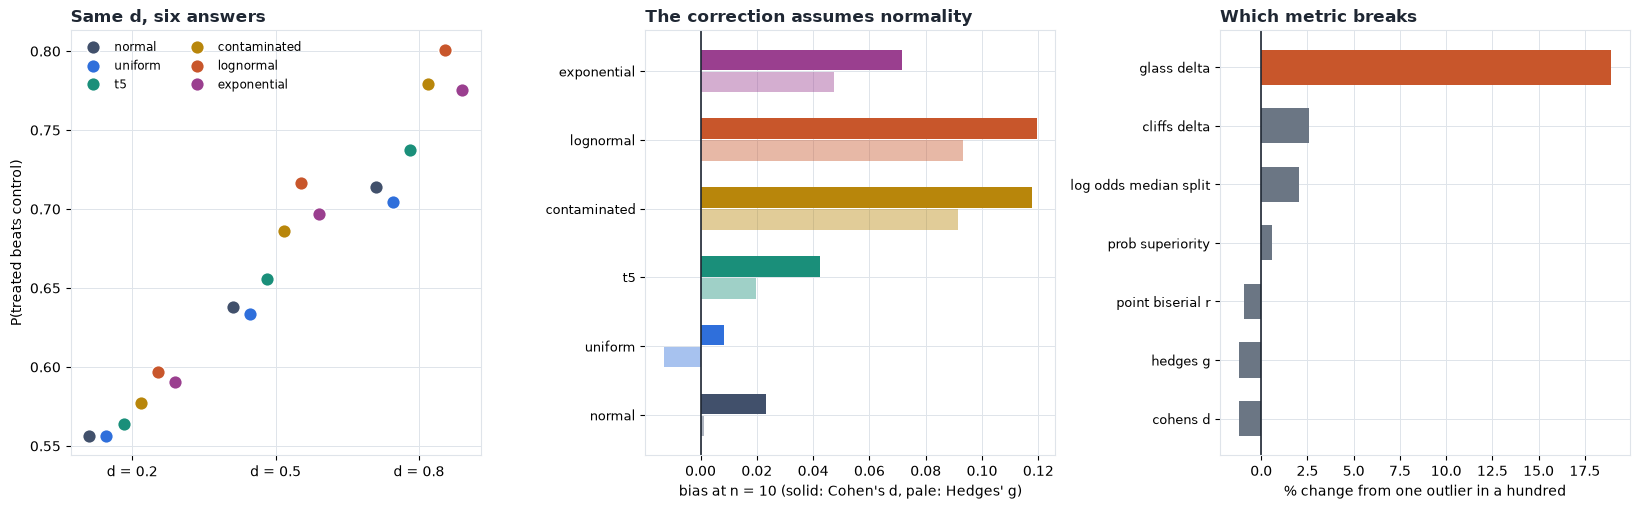

In [11]:
INK, MUTED, GRID, BG = "#1f2733", "#6b7684", "#dfe4ea", "#ffffff"
SC = {"normal": "#41506b", "uniform": "#2f6fdb", "t5": "#1a8f7a",
      "contaminated": "#b8860b", "lognormal": "#c8562b", "exponential": "#9a3f8f"}

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2), facecolor=BG)
for ax in axes:
    ax.set_facecolor(BG); ax.grid(True, color=GRID, lw=0.7); ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_color(GRID)

# Dots on a shared baseline, not bars: the quantity of interest is the SPREAD within each d.
ax = axes[0]
x = np.arange(len(STUDY_DS))
for i, shape in enumerate(SHAPES):
    off = (i - (len(SHAPES) - 1) / 2) * 0.12
    ax.plot(x + off, [truths[(shape, d)][0] for d in STUDY_DS], "o", color=SC[shape], ms=10,
            mec=BG, mew=1.2, label=shape, zorder=3)
ax.set_xticks(x); ax.set_xticklabels([f"d = {d:g}" for d in STUDY_DS])
ax.set_ylabel("P(treated beats control)")
ax.legend(frameon=False, fontsize=8.5, ncol=2, loc="upper left")
ax.set_title("Same d, six answers", color=INK, fontsize=12, weight="bold", loc="left")

ax = axes[1]
y = np.arange(len(SHAPES))
for i, shape in enumerate(SHAPES):
    r = cells_out[(shape, 10)]
    ax.barh(i + 0.16, r["d"] - 0.5, height=0.3, color=SC[shape])
    ax.barh(i - 0.16, r["g"] - 0.5, height=0.3, color=SC[shape], alpha=0.42)
ax.axvline(0, color=INK, lw=1.2)
ax.set_yticks(y); ax.set_yticklabels(SHAPES, fontsize=9)
ax.set_xlabel("bias at n = 10 (solid: Cohen's d, pale: Hedges' g)")
ax.set_title("The correction assumes normality", color=INK, fontsize=12, weight="bold",
             loc="left")

ax = axes[2]
rs = sorted(rows, key=lambda r: r[1])
ax.barh(np.arange(len(rs)), [r[1] for r in rs],
        color=[SC["lognormal"] if abs(r[1]) > 10 else MUTED for r in rs], height=0.6)
ax.axvline(0, color=INK, lw=1.2)
ax.set_yticks(np.arange(len(rs)))
ax.set_yticklabels([r[0].replace("_", " ") for r in rs], fontsize=9)
ax.set_xlabel("% change from one outlier in a hundred")
ax.set_title("Which metric breaks", color=INK, fontsize=12, weight="bold", loc="left")

fig.tight_layout()
fig.savefig("notebook_figure.png", dpi=140, facecolor=BG)
plt.show()

## What to take away

1. At an **identical** true Cohen's d of 0.5, the probability of superiority ranges over about
   0.083 across six distribution shapes. d is not wrong - it is a ratio, and its denominator means
   different things in different shapes.
2. Reporting an effect size without saying *which one*, on *what shape*, with *what interval*, is
   reporting a number rather than a magnitude.
3. Glass's delta - recommended exactly when the treatment changes the spread - moves about +19% on
   one contaminated value in a hundred. Cohen's d moves about one percent, in the other direction.
4. At n = 100,000 the smallest effect a study can see is a 50.25% win rate. Significance stopped
   carrying information about magnitude long before that.
5. "Never dichotomise" is a claim about normal data, and measured on skewed data it is false.

The through-line: every one of these is the same mistake in a different costume - treating a
**summary** as if it were the **thing**. d, p, and "significant" are all summaries, and each one
throws away something different on the way out.

## Try your own

In [12]:
# --- Your comparison -------------------------------------------------------
# MY_SHAPE = "lognormal"     # normal / uniform / t5 / contaminated / lognormal / exponential
# MY_D     = 0.5             # true Cohen's d, held EXACTLY by construction
# MY_N     = 40              # per group
#
# ps_true, err = true_prob_superiority(MY_SHAPE, MY_D, 4_000_000, seed=0)
# rng = np.random.default_rng(0)
# a, b = draw_pair(MY_SHAPE, MY_D, MY_N, MY_N, 20000, rng)
# m = metrics(a, b)
#
# print(f"true Cohen's d          {MY_D}")
# print(f"true P(X>Y)             {ps_true:.4f}   (normal would say "
#       f"{analytic_prob_superiority(MY_D):.4f})")
# for k in METRICS:
#     print(f"{k:<24} {float(m[k].mean()):>8.4f}")
# print(f"n for 80% power         {n_for_significance(MY_D):,} per group")

# --- Or: how much does the shape alone move the answer? --------------------
# for s in SHAPES:
#     p, _ = true_prob_superiority(s, 0.5, 4_000_000, seed=0)
#     print(f"{s:<14} P(X>Y) = {p:.4f}")

---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](data-science-cookbook/effect-size-reader)

The same study runs as a Streamlit app where you pick the shape and drag d around:

```bash
pip install -r requirements.txt
streamlit run app.py
```

`evidence.py` regenerates every number above into `evidence.txt` and `results.json`, and `pytest`
asserts the findings - including that each predicate is *capable* of returning either answer, so
none of them is a constant wearing a test.

Sibling builds in this domain, all of which interrogate the **test**:
[`t-test-variants`](../t-test-variants) (which one),
[`normality-test-trap`](../normality-test-trap) and
[`assumption-pretest-cost`](../assumption-pretest-cost) (what the pretests cost),
[`p-value-dance`](../p-value-dance) (what the p-value does under replay). This one is the first
to leave the test alone and interrogate the **estimate**.